### Downstream analysis for MAGSs-HMM Annotation, module: mags_hmm_annotation
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup.yaml -p mags_hmmsearch --mags_hmmsearch_outfolder hmm_proka_paper

```

In [75]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)
library(pheatmap)

options(readr.show_col_types = FALSE)

In [76]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [77]:
raw_data <- as.data.frame(read_delim("../tables/mags_hmm_annotation/mags.tsv",
                       delim = "\t",
                       ))
rownames(raw_data) <- raw_data$HMM_model
raw_data$HMM_model <- NULL

In [78]:
View(raw_data[0:4, ])

,mag_9,mag_8,mag_1,mag_6,mag_3,mag_7,mag_5,mag_2,mag_11,mag_4,mag_10
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K00003,mag_9,mag_8,mag_1,mag_6,0,mag_7,mag_5,mag_2,0,mag_4,mag_10
K00004,mag_9,mag_8,0,mag_6,0,mag_7,mag_5,mag_2,mag_11,0,0
K00005,0,mag_8,0,0,0,0,mag_5,0,0,0,0
K00007,0,0,0,0,0,mag_7,0,0,0,0,0


In [79]:
binary_matrix <- as.data.frame(lapply(raw_data, function(x) ifelse(x != "0", 1, 0)))
rownames(binary_matrix) <- rownames(raw_data)
# Sort so mag_2 comes before mag_10
sorted_names <- str_sort(colnames(binary_matrix), numeric = TRUE)
binary_matrix <- binary_matrix[, sorted_names]
View(binary_matrix[0:4, ])


,mag_1,mag_2,mag_3,mag_4,mag_5,mag_6,mag_7,mag_8,mag_9,mag_10,mag_11
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
K00003,1,1,0,1,1,1,1,1,1,1,0
K00004,0,1,0,0,1,1,1,1,1,0,1
K00005,0,0,0,0,1,0,0,1,0,0,0
K00007,0,0,0,0,0,0,1,0,0,0,0


In [80]:
# selecting carbon related KOs
kos_table <- as.data.frame(read_delim("../tables/ko_carbon_metab.csv",
  delim = ","
))

kos <- kos_table$ko
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- binary_matrix[present_kos, ]

In [81]:
# Carbon related KOs from 
# url_bige = 'https://raw.githubusercontent.com/ArnaudBelcour/bigecyhmm/refs/heads/main/bigecyhmm/hmm_databases/hmm_table_template.tsv'

kos <- c('K01938', 'K18861', 'K15231', 'K14466', 'K00197', 'K14469', 'K15230', 'K00198', 'K01601', 'K14467', 'K14468', 'K00194')
present_kos <- kos[kos %in% rownames(binary_matrix)]
final_matrix <- as.matrix(binary_matrix[present_kos, ])

In [82]:
class(present_kos)
dim(kos)
dim(final_matrix)

[1] "character"

NULL

[1]  5 11

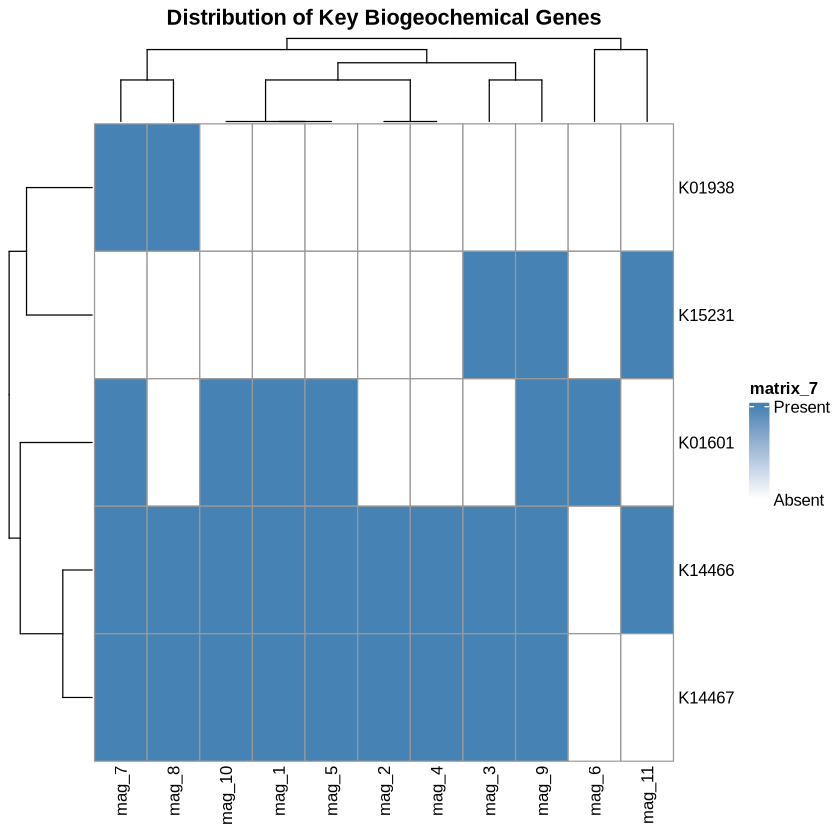

In [83]:
pheatmap(final_matrix, 
         color = c("white", "steelblue"), 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         legend_breaks = c(0, 1),
         legend_labels = c("Absent", "Present"),
         main = "Distribution of Key Biogeochemical Genes")

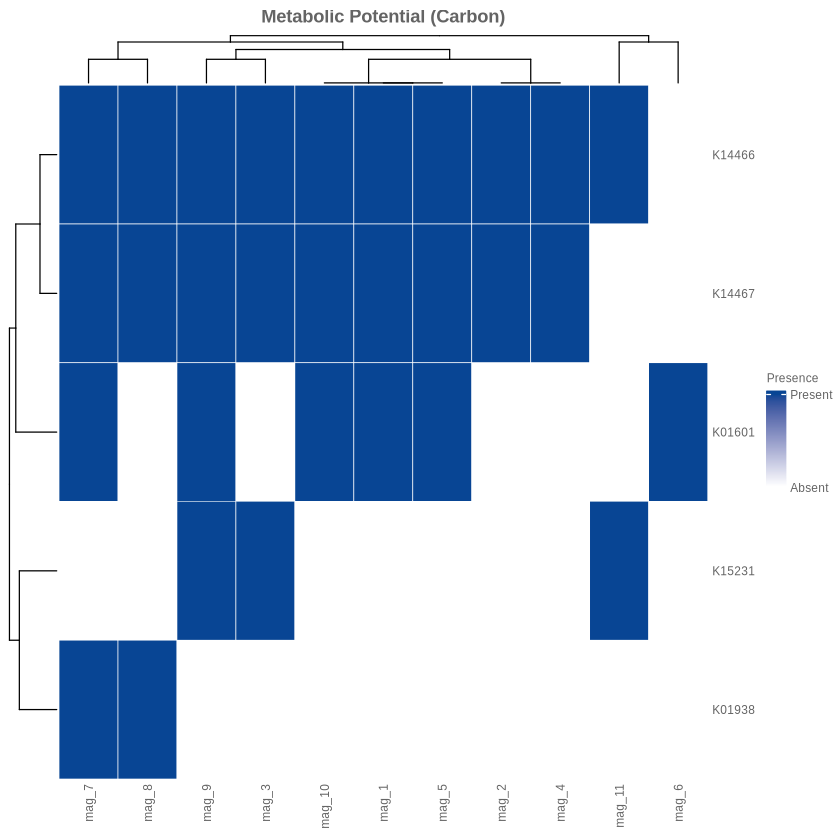

In [84]:
library(ComplexHeatmap)
library(circlize)
# 1. Define the core color from your theme_glab
glab_gray <- rgb(100, 100, 100, maxColorValue = 255)
# 2. Setup the Heatmap with theme_glab's visual identity
# Using your theme's font sizing (rel(0.65) of 11 is ~7.15)
ht <- Heatmap(final_matrix,
        name = "Presence",
        # Color palette: White to a bold Blue, consistent with your theme's clean BW base
        col = colorRamp2(c(0, 1), c("#FFFFFF", "#084594")),
        # Grid settings matching your panel.border and element_blank() grid
        rect_gp = gpar(col = "white", lwd = 0.5), 
        column_title = "Metabolic Potential (Carbon)",
        column_title_gp = gpar(col = glab_gray, fontsize = 11, fontface = "bold"),
        # Axis/Labels matching your axis.text and axis.title specs
        row_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        column_names_gp = gpar(col = glab_gray, fontsize = 7.15),
        # Clustering options
        cluster_rows = TRUE,
        cluster_columns = TRUE,
        # Legend styling matching your legend.text and legend.title
        heatmap_legend_param = list(
            title_gp = gpar(col = glab_gray, fontsize = 7.15),
            labels_gp = gpar(col = glab_gray, fontsize = 7.15),
            grid_height = unit(0.8, "lines"),
            at = c(0, 1),
            labels = c("Absent", "Present")
        )
)
# 3. Draw with a clean border matching your panel.border
draw(ht, padding = unit(c(2, 2, 2, 2), "mm"))

In [85]:
ht <- Heatmap(carbon_matrix, 
        name = "Presence", 
        col = col_fun,
        # Clustering & Structure
        cluster_rows = TRUE, 
        cluster_columns = TRUE,
        column_title = "Reconstructed MAGs (Carbon Metabolism)",
        row_title = "HMM Models (KOs)",
        # Visual Styling
        rect_gp = gpar(col = "white", lwd = 1), # White borders between tiles
        show_row_dend = TRUE, 
        show_column_dend = TRUE,
        # Legend Customization
        heatmap_legend_param = list(
            at = c(0, 1), 
            labels = c("Absent", "Present"),
            title = "Status"
        ),
        
        # Font settings for scientific readability
        row_names_gp = gpar(fontsize = 9, fontfamily = "sans"),
        column_names_gp = gpar(fontsize = 10, fontfamily = "sans")
)

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


ERROR: Error: object 'col_fun' not found


A) Phylogenetic tree of the obtained MAGs taxonomically identified using the GTDB-tk module and plotted using iTOL. B) Heatmap of the distribution of key biogeochemical genes obtained using the MAGs-HMM Annotation (MAG-HMMA) module and plotted in R.